<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [4]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [5]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [6]:
## Write your code here
import pandas as pd

# Define the URL of the dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'

# Load the dataset into a DataFrame
df = pd.read_csv(data_url)

# Display the column names
print("Column Names:")
print(df.columns)

# Display the data types of each column
print("\nData Types:")
print(df.dtypes)

# Display summary information about the dataset
print("\nSummary Information:")
print(df.info())

# Display basic descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
print(df.describe())

Column Names:
Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)

Data Types:
ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

Summary Information:
<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None

Descriptive Statistic

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [7]:
## Write your code here
import pandas as pd

# Define the URL of the dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'

# Load the dataset into a DataFrame
df = pd.read_csv(data_url)

# Step 3: Handle Missing Data

# Identify missing values
print("Missing Values by Column:")
print(df.isnull().sum())

# Impute missing values for numerical columns with the mean
df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].mean(), inplace=True)

# Impute missing values for categorical columns with the most frequent value
df['Employment'].fillna(df['Employment'].mode()[0], inplace=True)

# Optionally, drop rows with missing values in critical columns (e.g., 'JobSat', 'YearsCodePro')
df.dropna(subset=['JobSat', 'YearsCodePro'], inplace=True)

# Verify if there are still any missing values
print("\nMissing Values After Imputation/Removal:")
print(df.isnull().sum())

Missing Values by Column:
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

Missing Values After Imputation/Removal:


/tmp/ipykernel_600/730340698.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].mean(), inplace=True)
/tmp/ipykernel_600/730340698.py:20: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork                 9
                       ...  
JobSatPoints_11          115
SurveyLength             391
SurveyEase               352
ConvertedCompYearly    12317
JobSat                     0
Length: 114, dtype: int64


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [8]:
## Write your code here
import pandas as pd

# Define the URL of the dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'

# Load the dataset into a DataFrame
df = pd.read_csv(data_url)

# Step 4: Analyze Key Columns

# Calculate the value counts for the 'Employment' column
employment_counts = df['Employment'].value_counts()

# Calculate the value counts for the 'JobSat' column (Job Satisfaction)
job_sat_counts = df['JobSat'].value_counts()

# Calculate the value counts for the 'YearsCodePro' column (Professional Coding Experience)
years_code_pro_counts = df['YearsCodePro'].value_counts()

# Display the value counts for each column
print("Employment Distribution:")
print(employment_counts)
print("\nJob Satisfaction Distribution:")
print(job_sat_counts)
print("\nYears of Professional Coding Experience Distribution:")
print(years_code_pro_counts)

Employment Distribution:
Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking fo

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


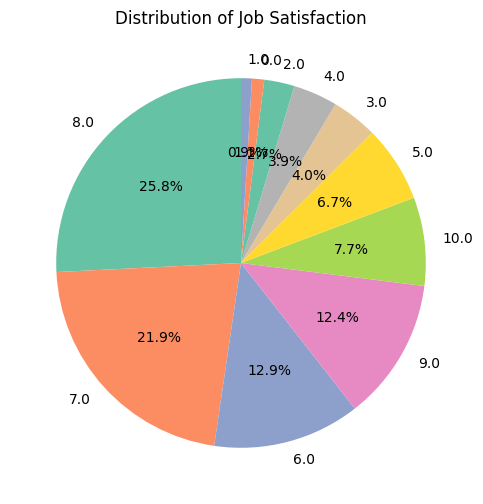

/tmp/ipykernel_600/3466547172.py:26: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['JobSat'].dropna(), shade=True, color='purple', bw_adjust=0.5)


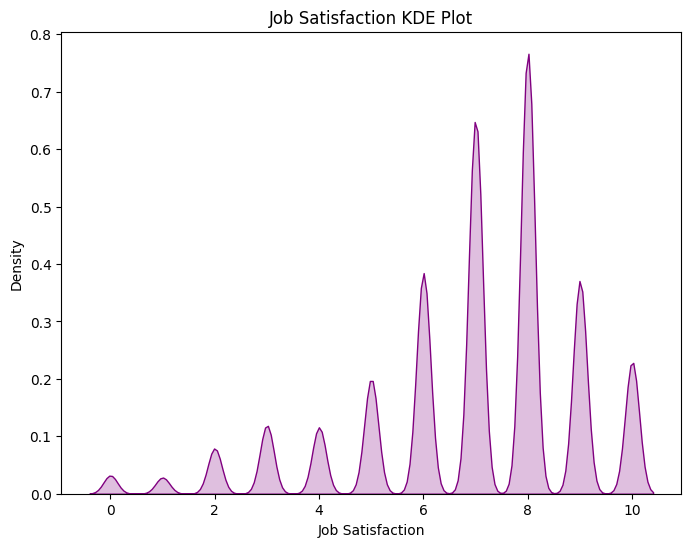

In [9]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the URL of the dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'

# Load the dataset into a DataFrame
df = pd.read_csv(data_url)

# Step 5: Visualize Job Satisfaction (Focus on JobSat)

# Pie chart to visualize the distribution of JobSat
job_sat_counts = df['JobSat'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 6))
job_sat_counts.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette("Set2"), startangle=90)
plt.title('Distribution of Job Satisfaction')
plt.ylabel('')  # Hide y-axis label
plt.show()

# Alternatively, KDE plot (though not ideal for categorical data)
plt.figure(figsize=(8, 6))
sns.kdeplot(df['JobSat'].dropna(), shade=True, color='purple', bw_adjust=0.5)
plt.title('Job Satisfaction KDE Plot')
plt.xlabel('Job Satisfaction')
plt.ylabel('Density')
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


In [10]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns

# Load the dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Step 6: Programming Languages Analysis

# Split the strings in both columns and create lists of languages
languages_have_worked_with = df['LanguageHaveWorkedWith'].dropna().str.split(',').explode().str.strip()
languages_want_to_work_with = df['LanguageWantToWorkWith'].dropna().str.split(',').explode().str.strip()

# Calculate the frequency of each language
have_worked_with_counts = languages_have_worked_with.value_counts()
want_to_work_with_counts = languages_want_to_work_with.value_counts()

# Create a Venn diagram to show the overlap between languages people have worked with and want to work with
plt.figure(figsize=(8, 6))
venn2(subsets=(set(have_worked_with_counts.index), set(want_to_work_with_counts.index)),
      set_labels=('Have Worked With', 'Want to Work With'))
plt.title("Venn Diagram of Programming Languages Have Worked With vs Want to Work With")
plt.show()

# Alternatively, create a grouped bar chart to show the counts of each language in both categories
# Merge the counts into a single DataFrame
languages_df = pd.DataFrame({
    'Have Worked With': have_worked_with_counts,
    'Want to Work With': want_to_work_with_counts
}).fillna(0)

# Plot the grouped bar chart
languages_df.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'lightgreen'])
plt.title("Comparison of Programming Languages Have Worked With vs Want to Work With")
plt.xlabel('Programming Languages')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.legend(title="Categories", loc="upper right")
plt.show()

ModuleNotFoundError: No module named 'matplotlib_venn'

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


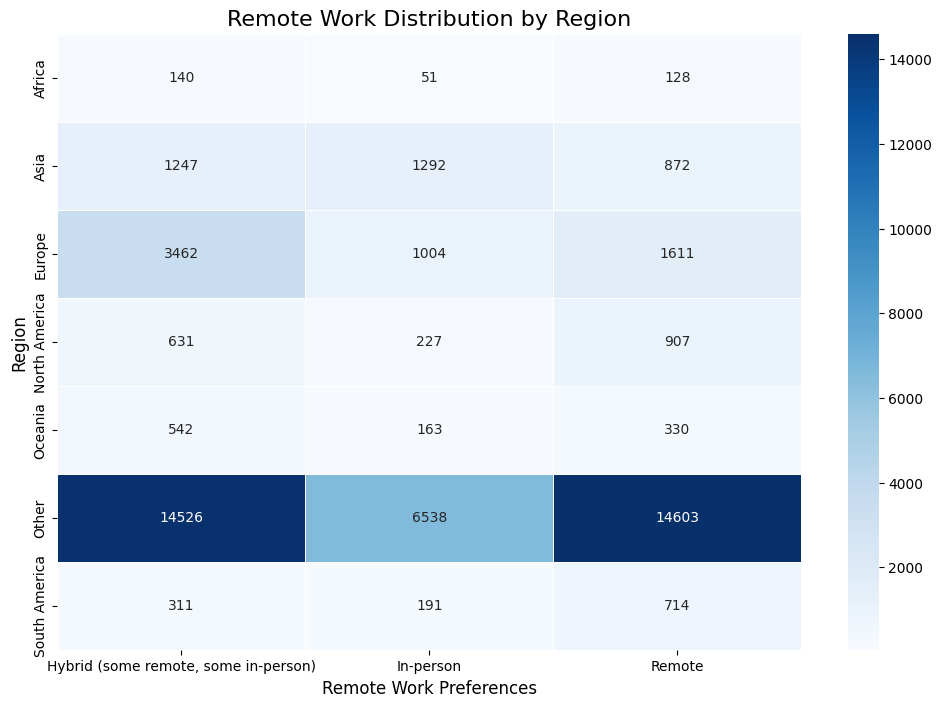

<Figure size 1200x800 with 0 Axes>

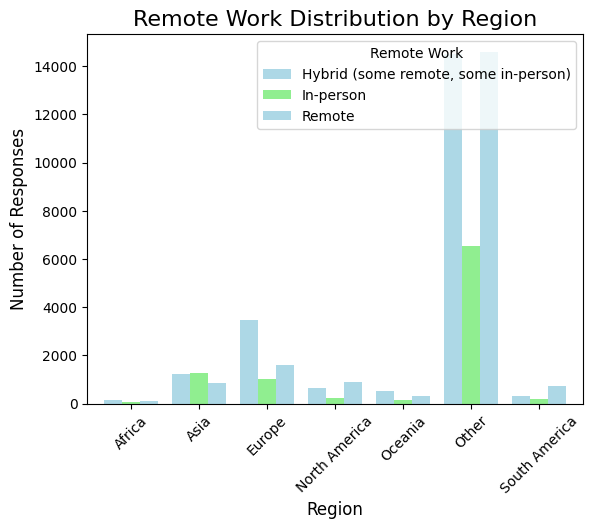

In [11]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Step 7: Analyze Remote Work Trends by Region

# Step 1: Handle missing values in Country and RemoteWork columns
df_cleaned = df.dropna(subset=['Country', 'RemoteWork'])

# Step 2: Map countries to regions (You can adjust the region mapping as per your dataset's countries)
region_map = {
    'United States': 'North America', 'Canada': 'North America',
    'Germany': 'Europe', 'France': 'Europe', 'United Kingdom': 'Europe',
    'India': 'Asia', 'China': 'Asia', 'Brazil': 'South America',
    'Australia': 'Oceania', 'South Africa': 'Africa'
}

# Add a new column for regions
df_cleaned['Region'] = df_cleaned['Country'].map(region_map).fillna('Other')

# Step 3: Calculate the distribution of RemoteWork preferences by Region
remote_work_dist = df_cleaned.groupby(['Region', 'RemoteWork']).size().unstack().fillna(0)

# Step 4: Create a heatmap to visualize the distribution of RemoteWork by region
plt.figure(figsize=(12, 8))
sns.heatmap(remote_work_dist, annot=True, cmap='Blues', fmt='g', cbar=True, linewidths=0.5)
plt.title("Remote Work Distribution by Region", fontsize=16)
plt.xlabel("Remote Work Preferences", fontsize=12)
plt.ylabel("Region", fontsize=12)
plt.show()

# Alternatively, create a grouped bar chart to show the distribution
plt.figure(figsize=(12, 8))
remote_work_dist.plot(kind='bar', stacked=False, color=['lightblue', 'lightgreen'], width=0.8)
plt.title("Remote Work Distribution by Region", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Number of Responses", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Remote Work", loc="upper right")
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [16]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 145.5 MB/s eta 0:00:0000:01


Pearson correlation between JobSat and YearsCodePro: 0.10
Spearman correlation between JobSat and YearsCodePro: 0.12


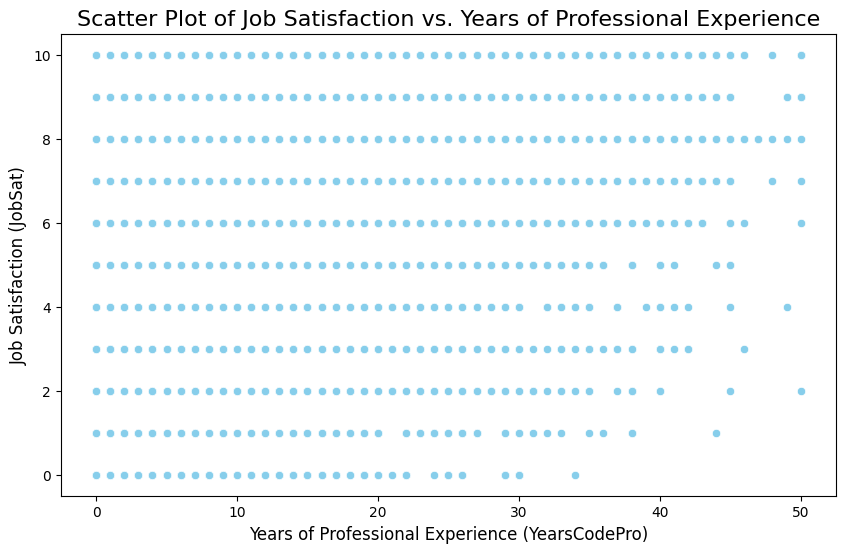

In [17]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Step 1: Clean the data by handling non-numeric entries in 'YearsCodePro'
# Replace text-based years (e.g., 'Less than 1 year') with numeric equivalents
df['YearsCodePro'] = df['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 50})

# Convert 'YearsCodePro' to numeric, coercing any errors into NaN
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Drop rows with missing values in 'JobSat' or 'YearsCodePro'
df_cleaned = df.dropna(subset=['JobSat', 'YearsCodePro'])

# Step 2: Calculate the Pearson correlation coefficient (for linear correlation)
# Ensure 'JobSat' is numeric by replacing or encoding categorical values if necessary
df_cleaned['JobSat'] = pd.to_numeric(df_cleaned['JobSat'], errors='coerce')

# Calculate correlation
pearson_corr = df_cleaned['JobSat'].corr(df_cleaned['YearsCodePro'], method='pearson')
print(f"Pearson correlation between JobSat and YearsCodePro: {pearson_corr:.2f}")

# Alternatively, calculate the Spearman correlation coefficient (for non-linear/ordinal relationships)
spearman_corr = df_cleaned['JobSat'].corr(df_cleaned['YearsCodePro'], method='spearman')
print(f"Spearman correlation between JobSat and YearsCodePro: {spearman_corr:.2f}")

# Step 3: Visualize the relationship using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='YearsCodePro', y='JobSat', color='skyblue')
plt.title('Scatter Plot of Job Satisfaction vs. Years of Professional Experience', fontsize=16)
plt.xlabel('Years of Professional Experience (YearsCodePro)', fontsize=12)
plt.ylabel('Job Satisfaction (JobSat)', fontsize=12)
plt.show()

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


Cross-tabulation of Employment vs. Education Level:
EdLevel                                             Associate degree (A.A., A.S., etc.)  \
Employment                                                                                
Employed, full-time                                                                1059   
Employed, full-time;Employed, part-time                                               9   
Employed, full-time;Independent contractor, fre...                                  104   
Employed, full-time;Independent contractor, fre...                                   11   
Employed, full-time;Independent contractor, fre...                                    0   
...                                                                                 ...   
Student, full-time;Student, part-time;Retired                                         0   
Student, part-time                                                                   12   
Student, part-time;Employed, part-time

/tmp/ipykernel_600/157826636.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


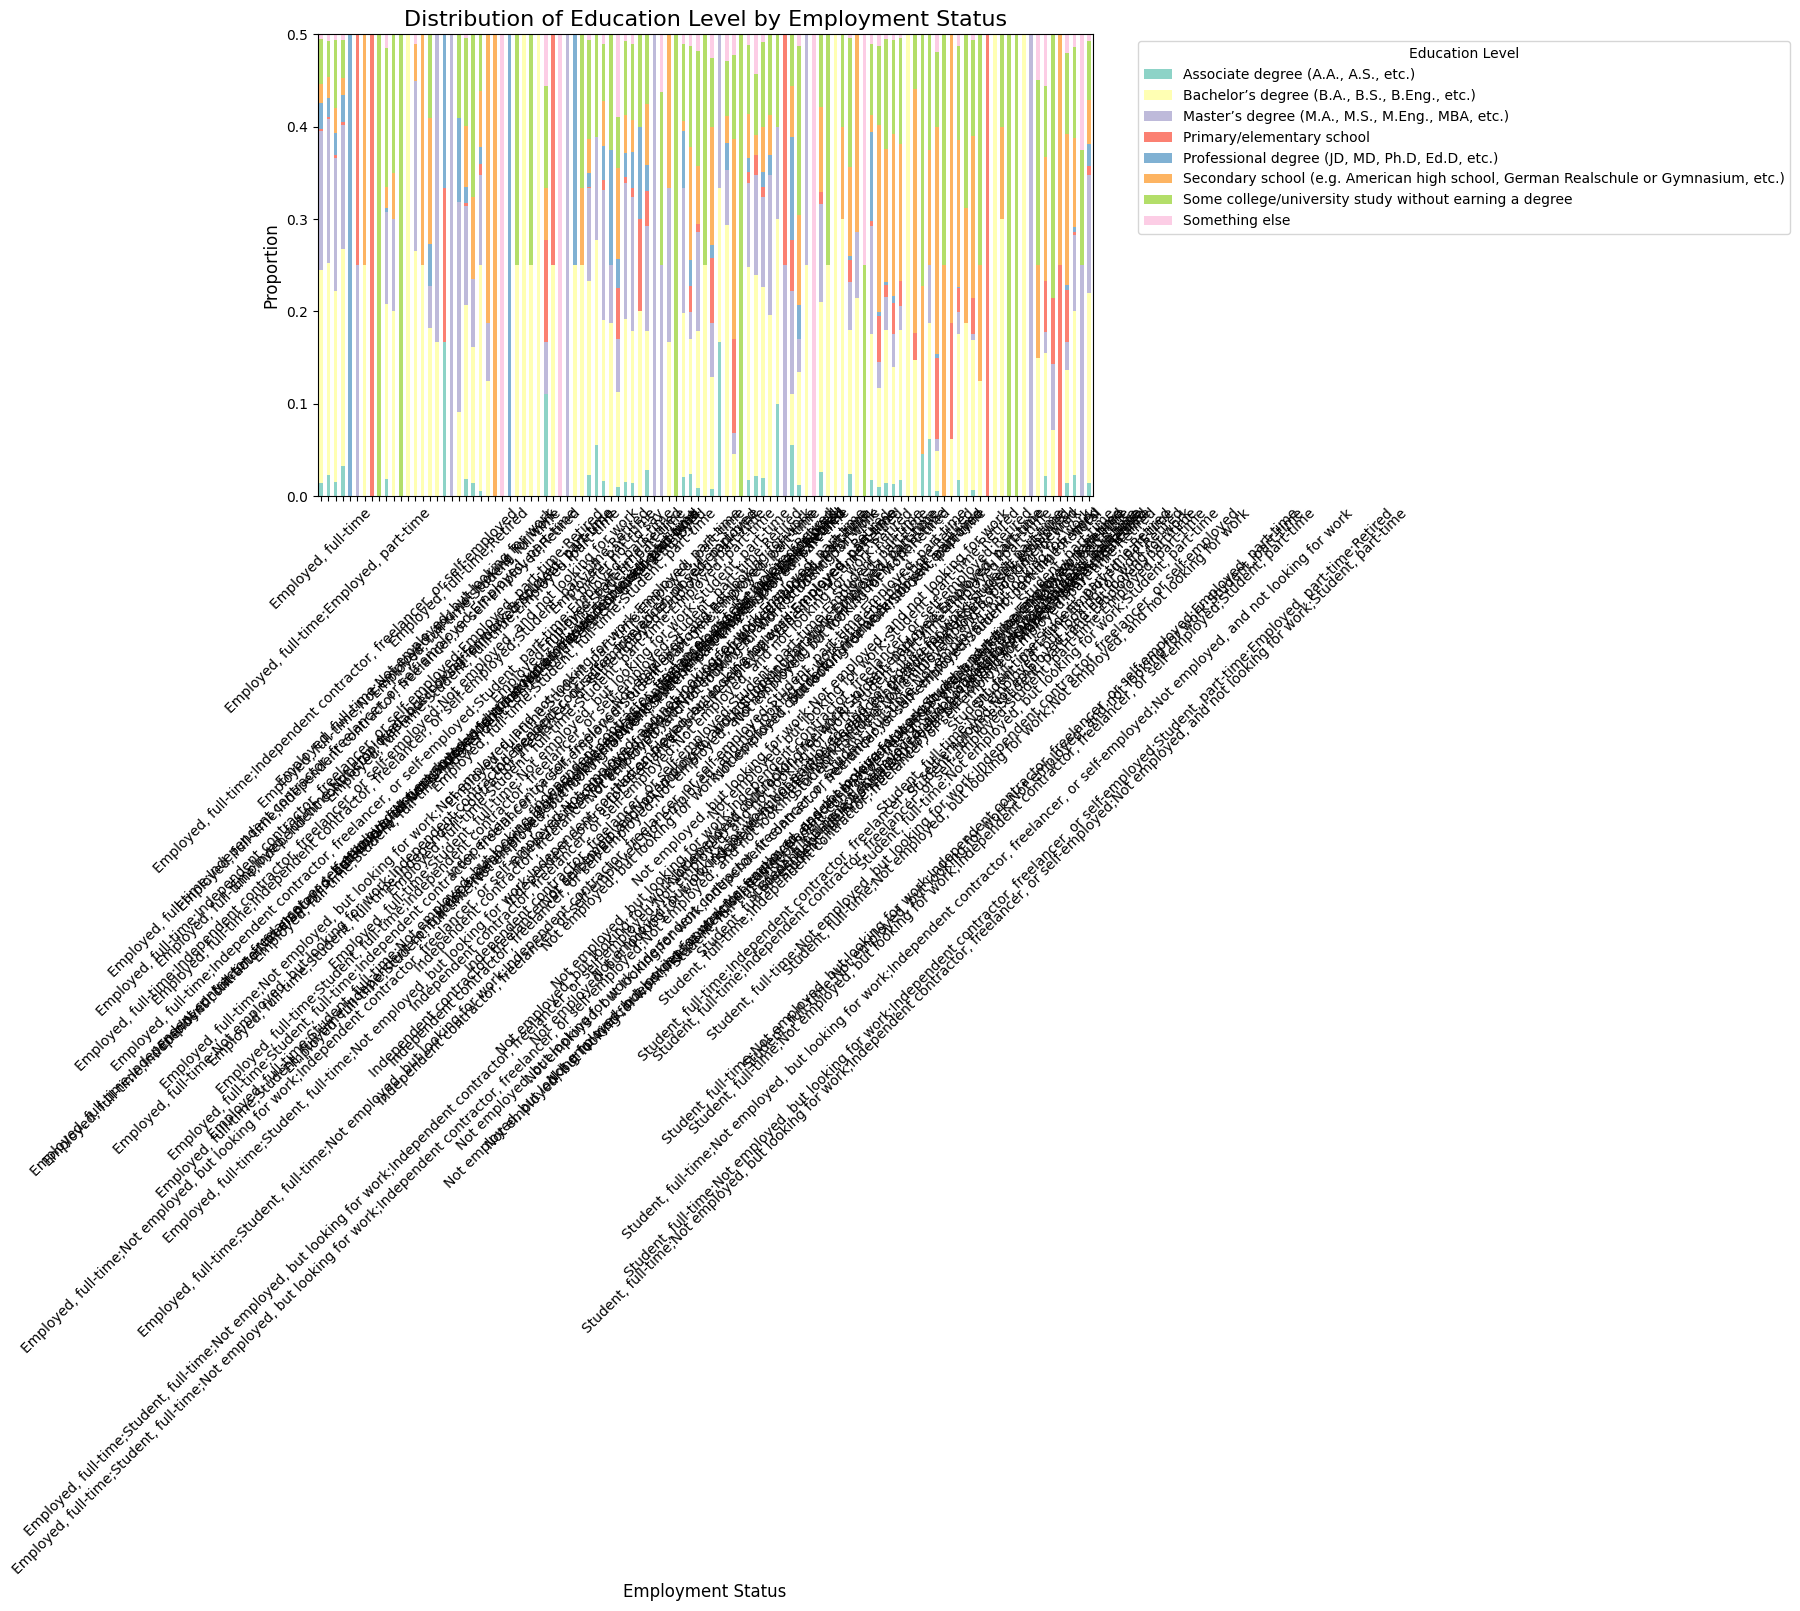

In [15]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Step 1: Create a cross-tabulation of Employment vs. Education Level
employment_vs_edlevel = pd.crosstab(df['Employment'], df['EdLevel'], margins=True, margins_name="Total")

# Display the cross-tabulation
print("Cross-tabulation of Employment vs. Education Level:")
print(employment_vs_edlevel)

# Step 2: Visualize the cross-tabulation with a stacked bar plot
# Normalize to display proportions for each employment status
employment_vs_edlevel_normalized = employment_vs_edlevel.div(employment_vs_edlevel.sum(axis=1), axis=0)

# Plot the stacked bar chart
employment_vs_edlevel_normalized.drop('Total', axis=1).plot(kind='bar', stacked=True, figsize=(10, 6), color=sns.color_palette("Set3", len(employment_vs_edlevel.columns)-1))

plt.title("Distribution of Education Level by Employment Status", fontsize=16)
plt.xlabel("Employment Status", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [ ]:
## Write your code here


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
